In [1]:
import pandas as pd

In [4]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Pravalika.b\OneDrive\Documents\store.csv", encoding="latin1")

data.head()

,s,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
### Convert order date to datetime
data["Order Date"] = pd.to_datetime(data["Order Date"])

In [10]:
### date range
print("Start Date:", data["Order Date"].min())
print("End Date:",data["Order Date"].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


In [12]:
### create monthly sales time series
monthly_sales = (
    data.set_index("Order Date")
        .resample("MS")["Sales"]
        .sum()
        .reset_index()
)

In [13]:
### check for missing months
all_months=pd.date_range(
    start=monthly_sales["Order Date"].min(),
    end=monthly_sales["Order Date"].max(),
    freq="MS"
)
missing_months=all_months[
    ~all_months.isin(monthly_sales["Order Date"])
]
print("\nMissing Months:")
print(missing_months)


    


Missing Months:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [14]:
### fill missing months with 0 scales
monthly_sales = (
    monthly_sales
    .set_index("Order Date")
    .reindex(all_months, fill_value=0)
    .rename_axis("Order Date")
    .reset_index()
)

In [15]:
monthly_sales.rename(columns={"Sales": "Total Sales"}, inplace=True)

In [16]:
print("\nPrepared Time Series:")
print(monthly_sales.head(10))


Prepared Time Series:
  Order Date  Total Sales
0 2014-01-01   14236.8950
1 2014-02-01    4519.8920
2 2014-03-01   55691.0090
3 2014-04-01   28295.3450
4 2014-05-01   23648.2870
5 2014-06-01   34595.1276
6 2014-07-01   33946.3930
7 2014-08-01   27909.4685
8 2014-09-01   81777.3508
9 2014-10-01   31453.3930


In [17]:
monthly_sales.to_csv("prepared_monthly_sales.csv", index=False)

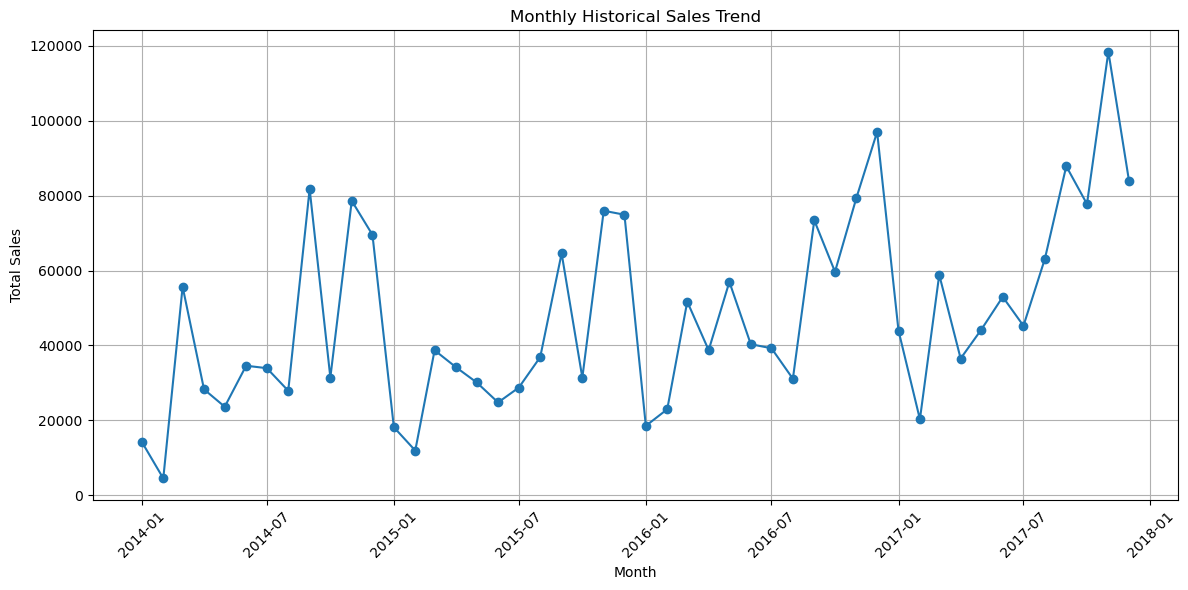

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Total Sales"],
    marker="o"
)

plt.title("Monthly Historical Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Conclusion
The Store Sales Time Series Analysis provided useful insights into the historical sales performance of the business.
The monthly sales analysis showed that sales experienced considerable fluctuations throughout the period, with several high and low
performing months. Despite these fluctuations, the overall sales performance showed improvement toward the later years, with the highest monthly sales
reaching approximately $118K in 2017.
The analysis also indicates the possibility of seasonal patterns in customer purchasing behavior. Understanding these patterns can help businesses
improve inventory planning, marketing strategies, and sales forecasting.
Overall, this project demonstrates how Python and time series analysis can be used to transform historical sales data into meaningful business 
insights.